In [32]:
import sys
from pathlib import Path 
import matplotlib.pyplot as plt 

import torch 
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
PKG_DIR = Path("/Users/hawardizayee/Desktop/AMI/eb_jepa/examples/my_image_jepa")
sys.path.insert(0, str(PKG_DIR))

from dataset import get_val_transforms

ckpt_dir = Path("/Users/hawardizayee/Desktop/AMI/eb_jepa_data/checkpoints/image_jepa/dev_2026-08-24_23-33/resnet_vicreg_proj_bs256_ep300_ph1024_po1024_std1.0_cov0.0_seed42")

# Data 

In [33]:
data_dir = "/Users/hawardizayee/Desktop/AMI/eb_jepa/datasets/cifar10"

# clean (no-augmentation) val transform: ToTensor + CIFAR-10 normalize
val_dataset = CIFAR10(root=data_dir, train=False, download=False, transform=get_val_transforms())
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, num_workers=0)

# one batch to feed the model:  images (256, 3, 32, 32) normalized, labels (256,)
images, labels = next(iter(val_loader))

# CIFAR-10 normalization stats (to undo normalization for display)
MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
STD  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)

def denorm(img):
    """(3,32,32) normalized tensor -> (32,32,3) array for imshow."""
    return (img * STD + MEAN).clamp(0, 1).permute(1, 2, 0).numpy()

images.shape

torch.Size([256, 3, 32, 32])

# Model 

In [34]:
latest = torch.load(ckpt_dir / "latest.pth.tar", map_location="cpu")
latest.keys()
latest["model_state_dict"].keys()

odict_keys(['backbone.backbone.conv1.weight', 'backbone.backbone.bn1.weight', 'backbone.backbone.bn1.bias', 'backbone.backbone.bn1.running_mean', 'backbone.backbone.bn1.running_var', 'backbone.backbone.bn1.num_batches_tracked', 'backbone.backbone.layer1.0.conv1.weight', 'backbone.backbone.layer1.0.bn1.weight', 'backbone.backbone.layer1.0.bn1.bias', 'backbone.backbone.layer1.0.bn1.running_mean', 'backbone.backbone.layer1.0.bn1.running_var', 'backbone.backbone.layer1.0.bn1.num_batches_tracked', 'backbone.backbone.layer1.0.conv2.weight', 'backbone.backbone.layer1.0.bn2.weight', 'backbone.backbone.layer1.0.bn2.bias', 'backbone.backbone.layer1.0.bn2.running_mean', 'backbone.backbone.layer1.0.bn2.running_var', 'backbone.backbone.layer1.0.bn2.num_batches_tracked', 'backbone.backbone.layer1.1.conv1.weight', 'backbone.backbone.layer1.1.bn1.weight', 'backbone.backbone.layer1.1.bn1.bias', 'backbone.backbone.layer1.1.bn1.running_mean', 'backbone.backbone.layer1.1.bn1.running_var', 'backbone.backbo

In [35]:
from model import ResNet18, ImageSSL

# ckpt dir name encodes the config:  resnet ... ph1024_po1024  -> hidden/output = 1024
backbone = ResNet18()
model = ImageSSL(
    backbone,
    features_dim=backbone.features_dim,   # 512
    proj_hidden_dim=1024,
    proj_output_dim=1024,
)

model.load_state_dict(latest["model_state_dict"])

<All keys matched successfully>

# Compare Cat and ship

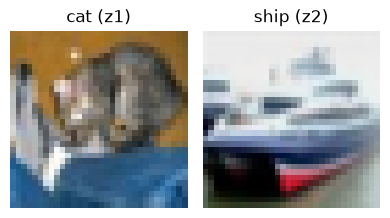

z1 (cat) : (1024,)
z2 (ship): (1024,)


In [36]:
model.eval()  # eval mode -> BatchNorm uses running stats (important for a 2-image batch)

# CIFAR-10 class ids
cat_id  = val_dataset.class_to_idx["cat"]    # 3
ship_id = val_dataset.class_to_idx["ship"]   # 8

# first cat and first ship in the loaded batch
cat_idx  = (labels == cat_id).nonzero()[0].item()
ship_idx = (labels == ship_id).nonzero()[0].item()

pair = torch.stack([images[cat_idx], images[ship_idx]])   # (2, 3, 32, 32)

with torch.no_grad():
    _, z = model(pair)          # projector output = the VICReg embedding

z1, z2 = z[0], z[1]             # z1 = cat, z2 = ship

# show the two images being compared
fig, axes = plt.subplots(1, 2, figsize=(4, 2.2))
for ax, i, name in zip(axes, [cat_idx, ship_idx], ["cat (z1)", "ship (z2)"]):
    ax.imshow(denorm(images[i])); ax.set_title(name); ax.axis("off")
plt.tight_layout(); plt.show()

print("z1 (cat) :", tuple(z1.shape))
print("z2 (ship):", tuple(z2.shape))

In [37]:
print(z1)
print(z2)

tensor([ 0.6965,  0.7021,  0.6551,  ..., -0.6555,  0.6545, -0.6671])
tensor([-1.2067, -1.2019, -1.2493,  ...,  1.2479, -1.2494,  1.2354])


# Collapsed embeddings 

In [38]:
embeding_history = torch.load(ckpt_dir / "embedding_history.pt")

### Regarding HingeLoss 

In [39]:
import numpy as np
import plotly.graph_objects as go

# HingeStdLoss: max(0, mu - std) per feature. std >= mu -> no penalty.
mu = 1.0
s = np.linspace(0, 5, 500)
loss = np.maximum(0.0, mu - s)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=s, y=loss, mode="lines",
    line=dict(color="royalblue", width=3),
    name="max(0, μ − std)",
))

# mu threshold marker
fig.add_vline(
    x=mu, line=dict(color="gray", dash="dash", width=1),
    annotation_text="μ = 1", annotation_position="bottom right",
    annotation_font_color="gray",
)

fig.update_layout(
    title="Hinge (std) loss: penalize only when std falls below μ",
    xaxis_title="per-feature std  √(Var(x<sub>d</sub>) + ε)",
    yaxis_title="ℒ<sub>std</sub> contribution",
    plot_bgcolor="white",
    width=680, height=430,
    legend=dict(x=0.98, y=0.98, xanchor="right", yanchor="top",
                bordercolor="lightgray", borderwidth=1),
)
fig.update_xaxes(range=[0, 5], showgrid=True, gridcolor="lightgray",
                 zeroline=False, showline=True, linecolor="black", mirror=True)
fig.update_yaxes(range=[0, 1.05], showgrid=True, gridcolor="lightgray",
                 zeroline=False, showline=True, linecolor="black", mirror=True)
fig.show()

In [40]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# one sample per CIFAR-10 class -> 10 distinct rows, all 10 classes
targets = np.array(val_dataset.targets)
class_idx = [int(np.where(targets == c)[0][0]) for c in range(10)]
class_names = [val_dataset.classes[c] for c in range(10)]
batch = torch.stack([val_dataset[i][0] for i in class_idx])          # (10, 3, 32, 32)

model.eval()
with torch.no_grad():
    _, z1 = model(batch)          # projector output = the VICReg embedding, (10, 1024)

# 32 RANDOM features out of the 1024-dim projection (seeded for a stable figure)
rng = np.random.default_rng(0)
feat_idx = np.sort(rng.choice(z1.shape[1], size=32, replace=False))
z = z1[:, feat_idx].numpy()       # (10, 32)
std = z.std(axis=0)               # per-feature std across the 10 classes

fig = make_subplots(
    rows=2, cols=1, shared_xaxes=True,
    row_heights=[0.9, 0.1], vertical_spacing=0.05,
)

# main heatmap: rows = class, cols = random feature subset.
# xgap + ygap -> white grid (shows through against dark viridis cells)
fig.add_trace(
    go.Heatmap(
        z=z,
        y=class_names,
        colorscale="Viridis",
        xgap=1, ygap=2,
        colorbar=dict(title="embeddings", len=0.72, y=0.62),
    ),
    row=1, col=1,
)

# thin std bar: pinned to a healthy reference (0..1). std1 keeps per-feature std ~1 -> bright.
fig.add_trace(
    go.Heatmap(
        z=std[None, :],
        y=["per-feature std"],
        colorscale="Magma",
        zmin=0.0, zmax=1.0,
        showscale=True,
        colorbar=dict(title="std", len=0.35, y=0.10, thickness=16, tickvals=[0.0, 0.5, 1.0]),
    ),
    row=2, col=1,
)

# std cells are bright, so white gaps are invisible -> draw gray separator lines instead
for b in np.arange(0.5, len(feat_idx) - 1 + 0.5, 1.0):
    fig.add_vline(x=b, row=2, col=1, line_width=1, line_color="gray")

fig.update_layout(
    plot_bgcolor="white",
    height=520, width=820,
)
fig.update_xaxes(title_text="random feature subset (of 1024)", row=2, col=1)
fig.update_yaxes(autorange="reversed", row=1, col=1)  # class 0 on top, like imshow
fig.show()

### Regarding Cov Loss 

In [41]:
Z1 = embeding_history["z1_history"][-1]
Z1.shape

torch.Size([256, 1024])

In [42]:
Z1 = Z1 - Z1.mean(dim=0, keepdim=True)
cov = Z1.T @ Z1 
print(cov.shape ) 
print("----"*30)
print(cov)

torch.Size([1024, 1024])
------------------------------------------------------------------------------------------------------------------------
tensor([[ 300.4637,  300.5006,  300.5182,  ..., -300.4128,  300.4914,
         -300.3130],
        [ 300.5006,  300.5378,  300.5551,  ..., -300.4500,  300.5284,
         -300.3498],
        [ 300.5182,  300.5551,  300.5724,  ..., -300.4673,  300.5458,
         -300.3672],
        ...,
        [-300.4128, -300.4500, -300.4673,  ...,  300.3623, -300.4409,
          300.2622],
        [ 300.4914,  300.5284,  300.5458,  ..., -300.4409,  300.5192,
         -300.3406],
        [-300.3130, -300.3498, -300.3672,  ...,  300.2622, -300.3406,
          300.1623]])


In [43]:
import plotly.graph_objects as go

cov_np = cov.numpy()            # (1024, 1024)

# std1/cov0: entries are large and near-equal in magnitude (~hundreds), not ~0.
# symmetric scale (+/-M) with 0 -> white, so sign of each covariance is readable.
M = np.abs(cov_np).max()

fig = go.Figure(go.Heatmap(
    z=cov_np,
    colorscale="RdBu", reversescale=True,   # red = +, blue = -  (matches matplotlib RdBu_r)
    zmin=-M, zmax=M, zmid=0,
    colorbar=dict(title="cov"),
))
fig.update_layout(
    title=(
        "cov(Z) — full 1024×1024  (std1 / cov0)"
        f"<br><sup>max |entry| = {M:.0f} · every feature pair strongly correlated → rank-1 (dimensional collapse)</sup>"
    ),
    xaxis_title="feature",
    yaxis_title="feature",
    width=600, height=580,
    plot_bgcolor="white",
)
fig.update_yaxes(autorange="reversed", scaleanchor="x", constrain="domain")  # square, feature 0 top-left
fig.update_xaxes(constrain="domain")
fig.show()

In [44]:
std = Z1.std(0)
print(std.min().item(), std.median().item(), std.max().item())  # orders of magnitude matter

# correlation matrix: decouples "is there variance?" from "is it redundant?"
# C = torch.corrcoef(Z1.T)   # ill-defined under collapse — informative in itself

# effective rank: catches *dimensional* collapse, which a uniform std bar won't
ev = torch.linalg.eigvalsh(torch.cov(Z1.T)).clamp(min=0)
p = ev / ev.sum()
print("eff. rank:", torch.exp(-(p * (p + 1e-12).log()).sum()).item())  # 1024 = ideal, ~1 = collapsed

1.0846619606018066 1.0853644609451294 1.0861867666244507
eff. rank: 1.0000648498535156
